# 📱 Mobile Market Segmenter
## Using K-Nearest Neighbors (KNN) Classification

---

### 🎯 Project Objective
Classify mobile users into different behavioral segments based on their device usage patterns, demographics, and app engagement metrics using the K-Nearest Neighbors algorithm.

### 📊 Dataset
**Source:** [Mobile Device Usage and User Behavior Dataset - Kaggle](https://www.kaggle.com/datasets/valakhorasani/mobile-device-usage-and-user-behavior-dataset)
- **Samples:** 700 mobile users
- **Features:** Device info, usage patterns, demographics
- **Target:** User Behavior Class (segmentation)

### 🛠️ Tech Stack
- Python 3.x
- Pandas, NumPy (data manipulation)
- Scikit-learn (machine learning)
- Matplotlib, Seaborn (visualization)

### 👨‍💻 Author
Mayank | Data Science Portfolio Project

---


In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score
)

## 📊 PART 1: Data Loading & Initial Inspection


In [8]:
df = pd.read_csv('user_behavior_dataset.csv')

In [9]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [10]:
df.shape

(700, 11)

In [11]:
df.isnull().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [15]:
df.describe()

,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [16]:
df.dtypes.value_counts()

int64      7
object     3
float64    1
Name: count, dtype: int64

In [17]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
User ID,700.0,350.500000,202.216880,1.0,175.75,350.5,525.25,700.0
App Usage Time (min/day),700.0,271.128571,177.199484,30.0,113.25,227.5,434.25,598.0
Screen On Time (hours/day),700.0,5.272714,3.068584,1.0,2.50,4.9,7.40,12.0
Battery Drain (mAh/day),700.0,1525.158571,819.136414,302.0,722.25,1502.5,2229.50,2993.0
Number of Apps Installed,700.0,50.681429,26.943324,10.0,26.00,49.0,74.00,99.0
Data Usage (MB/day),700.0,929.742857,640.451729,102.0,373.00,823.5,1341.00,2497.0
Age,700.0,38.482857,12.012916,18.0,28.00,38.0,49.00,59.0
User Behavior Class,700.0,2.990000,1.401476,1.0,2.00,3.0,4.00,5.0


In [19]:
# Check unique values in each column


for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col:30s} → {unique_count:4d} unique values")
    
    if unique_count <= 10:
        print(f"   Values: {df[col].unique()[:10]}")
    print()


User ID                        →  700 unique values

Device Model                   →    5 unique values
   Values: ['Google Pixel 5' 'OnePlus 9' 'Xiaomi Mi 11' 'iPhone 12'
 'Samsung Galaxy S21']

Operating System               →    2 unique values
   Values: ['Android' 'iOS']

App Usage Time (min/day)       →  387 unique values

Screen On Time (hours/day)     →  108 unique values

Battery Drain (mAh/day)        →  628 unique values

Number of Apps Installed       →   86 unique values

Data Usage (MB/day)            →  585 unique values

Age                            →   42 unique values

Gender                         →    2 unique values
   Values: ['Male' 'Female']

User Behavior Class            →    5 unique values
   Values: [4 3 2 5 1]



In [22]:


target_col = 'User Behavior Class' 

target_col in df.columns
print(f"Class Distribution:\n")
class_counts = df[target_col].value_counts()
class_percent = df[target_col].value_counts(normalize=True) * 100
    
result_df = pd.DataFrame({
        'Count': class_counts,
        'Percentage': class_percent
    })
    
print(result_df)
print(f"\n📊 Total Classes: {df[target_col].nunique()}")



Class Distribution:

                     Count  Percentage
User Behavior Class                   
2                      146   20.857143
3                      143   20.428571
4                      139   19.857143
5                      136   19.428571
1                      136   19.428571

📊 Total Classes: 5


Exploratory Data Analysis (EDA)

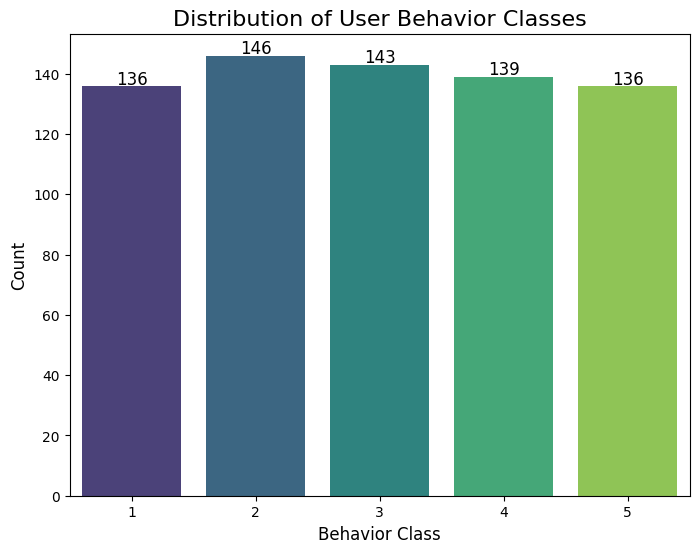

In [23]:
# Set up the figure size
plt.figure(figsize=(8, 6))

# Plot the distribution of the target variable
target_col = 'User Behavior Class'

sns.countplot(x=target_col, data=df, palette='viridis')

plt.title('Distribution of User Behavior Classes', fontsize=16)
plt.xlabel('Behavior Class', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add count labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.show()


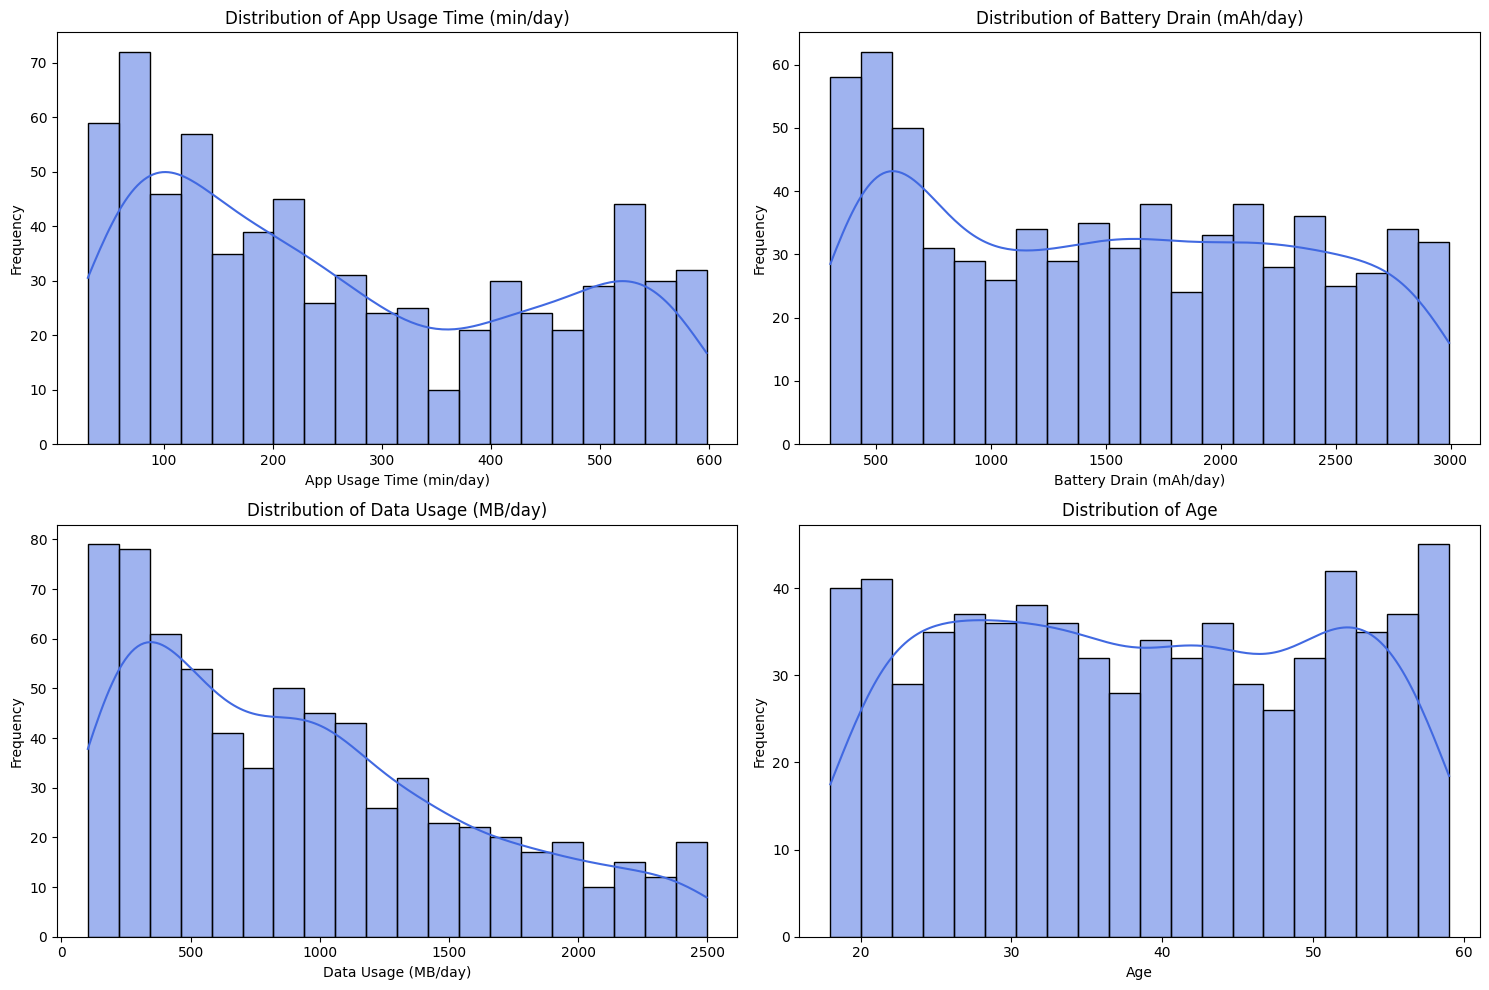

In [24]:
# Select key numerical columns to visualize
num_cols = ['App Usage Time (min/day)', 'Battery Drain (mAh/day)', 
            'Data Usage (MB/day)', 'Age']

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=20, color='royalblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


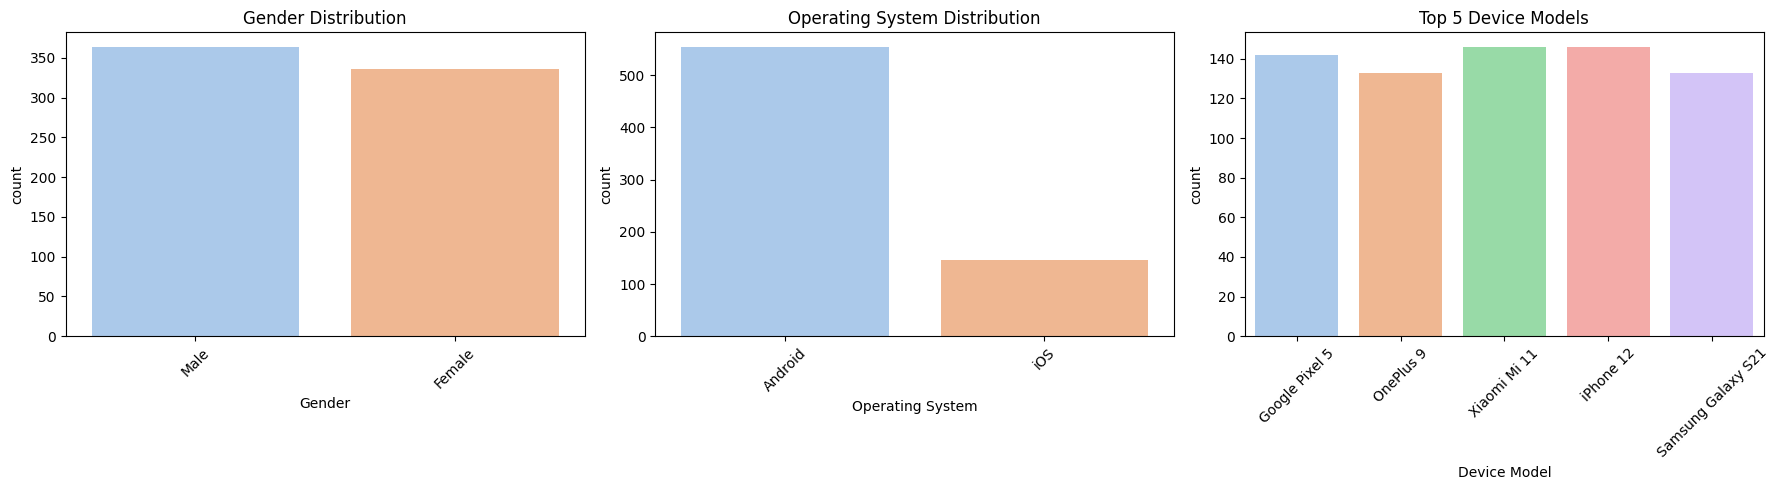

In [25]:
# Categorical columns to analyze
cat_cols = ['Gender', 'Operating System', 'Device Model']

plt.figure(figsize=(18, 5))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    
    # Get top 10 categories for Device Model to avoid clutter
    if col == 'Device Model':
        top_devices = df[col].value_counts().nlargest(5).index
        sns.countplot(x=col, data=df[df[col].isin(top_devices)], palette='pastel')
        plt.title(f'Top 5 {col}s')
    else:
        sns.countplot(x=col, data=df, palette='pastel')
        plt.title(f'{col} Distribution')
        
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


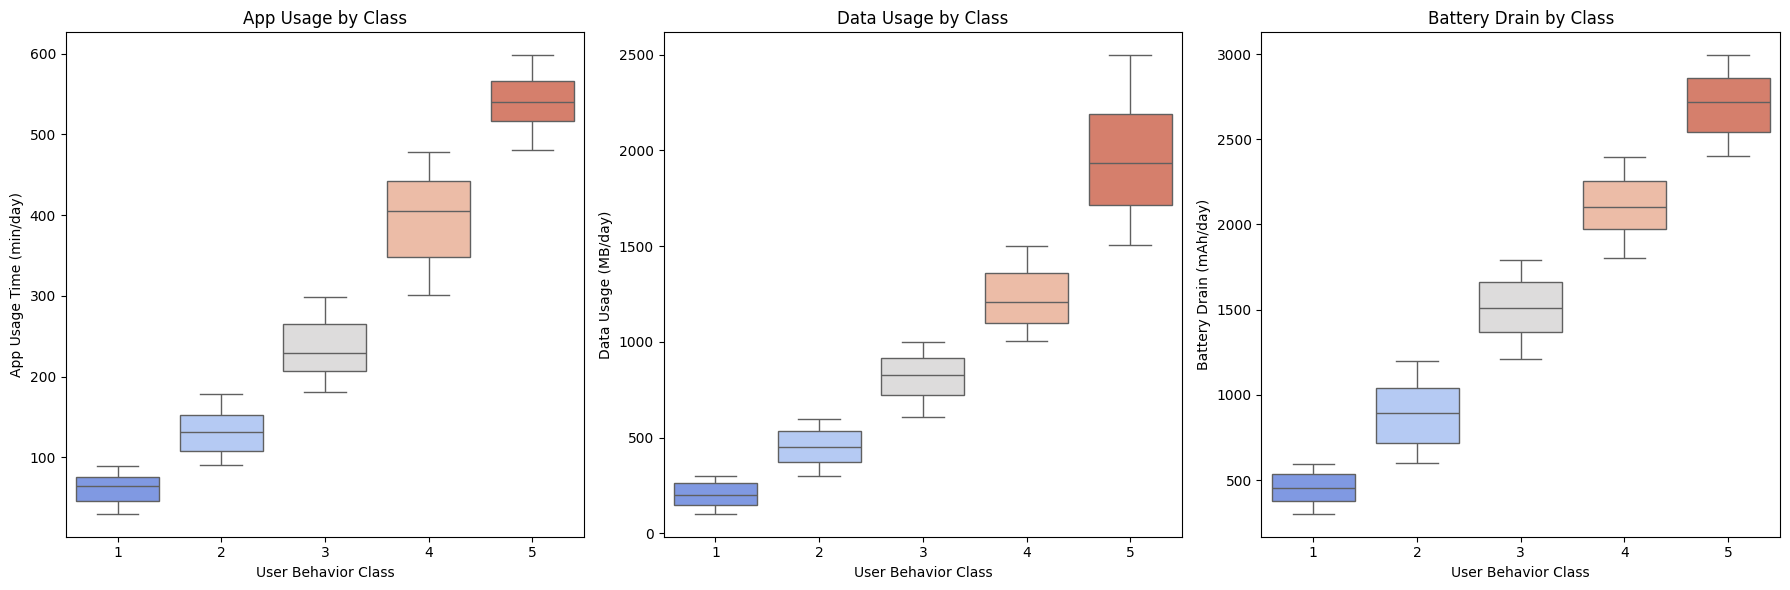

In [26]:
# Relationship between Usage Metrics and User Class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='User Behavior Class', y='App Usage Time (min/day)', data=df, ax=axes[0], palette='coolwarm')
axes[0].set_title('App Usage by Class')

sns.boxplot(x='User Behavior Class', y='Data Usage (MB/day)', data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Data Usage by Class')

sns.boxplot(x='User Behavior Class', y='Battery Drain (mAh/day)', data=df, ax=axes[2], palette='coolwarm')
axes[2].set_title('Battery Drain by Class')

plt.tight_layout()
plt.show()


In [27]:
#5 rows of user behavior class column
df['User Behavior Class'].head()

0    4
1    3
2    2
3    3
4    3
Name: User Behavior Class, dtype: int64

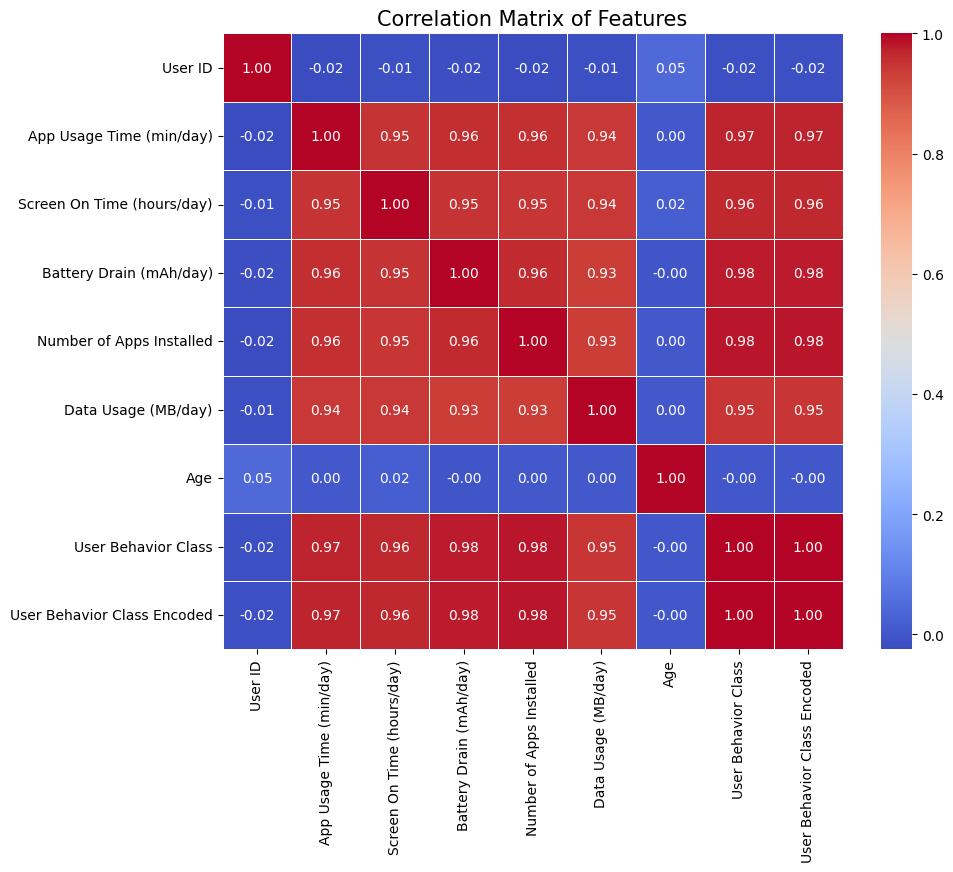

In [30]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Features', fontsize=15)
plt.show()


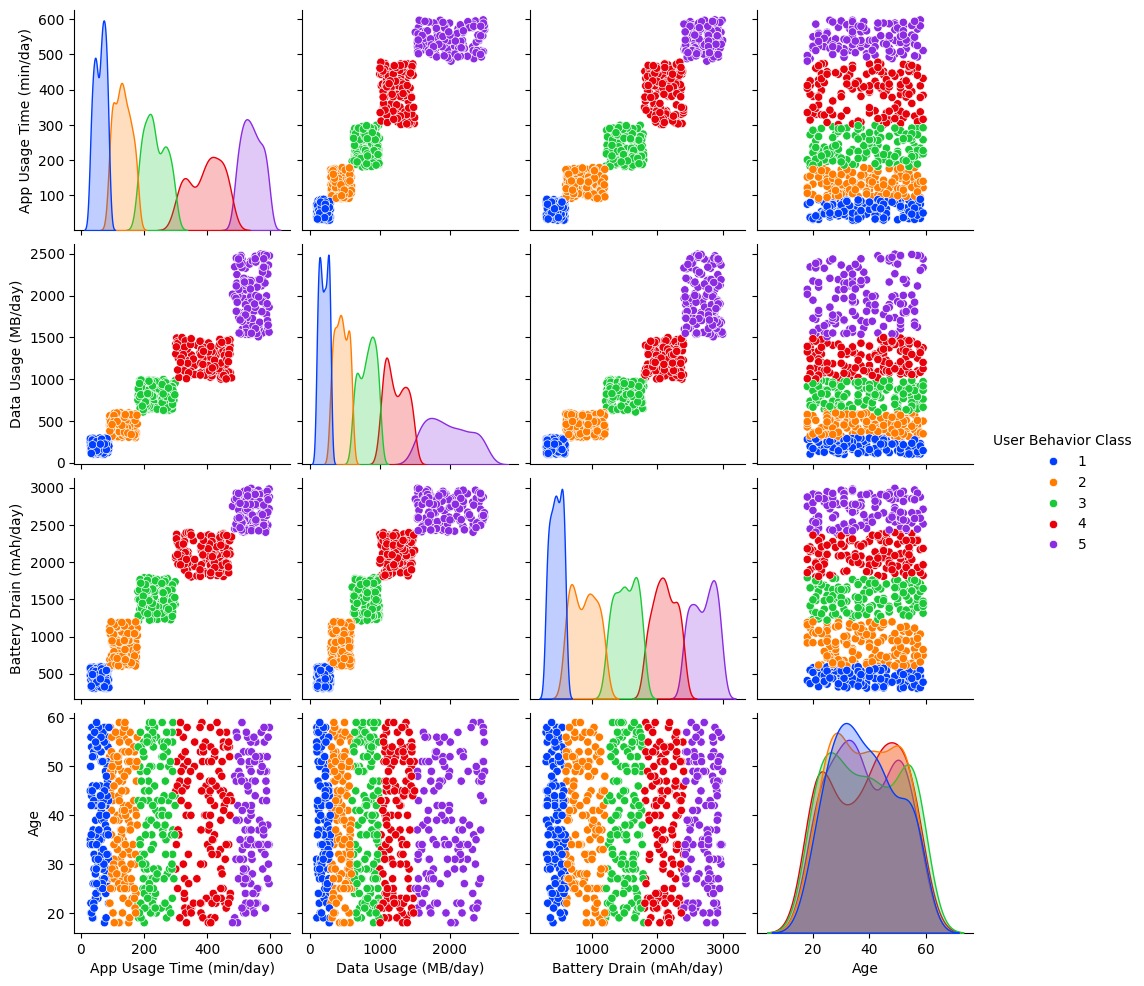

In [31]:
# Pairplot to see clusters
# We'll select a subset of important columns to keep the plot readable
cols_to_plot = ['App Usage Time (min/day)', 'Data Usage (MB/day)', 
                'Battery Drain (mAh/day)', 'Age', 'User Behavior Class']

sns.pairplot(df[cols_to_plot], hue='User Behavior Class', palette='bright', diag_kind='kde')
plt.show()


 Data Preprocessing

In [32]:
X = df.drop(['User ID', 'User Behavior Class'], axis=1)
y = df['User Behavior Class']

In [33]:
categorical_cols = ['Device Model', 'Operating System', 'Gender']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [34]:
le = LabelEncoder()
y = le.fit_transform(y)

print("✅ Data Encoded Successfully!")
print(f"Features shape: {X.shape}")
print(f"Target classes: {le.classes_}")
print("\n👀 First 3 rows of processed features:")
X.head(3)

✅ Data Encoded Successfully!
Features shape: (700, 13)
Target classes: [1 2 3 4 5]

👀 First 3 rows of processed features:


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class Encoded,Device Model_OnePlus 9,Device Model_Samsung Galaxy S21,Device Model_Xiaomi Mi 11,Device Model_iPhone 12,Operating System_iOS,Gender_Male
0,393,6.4,1872,67,1122,40,3,False,False,False,False,False,True
1,268,4.7,1331,42,944,47,2,True,False,False,False,False,False
2,154,4.0,761,32,322,42,1,False,False,True,False,False,True


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [36]:
X_train.shape[0]

560

In [37]:
X_test.shape[0]

140

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [40]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Features Scaled (Mean ≈ 0, Std ≈ 1)")
print("\n👀 Preview of scaled data:")
X_train_scaled.head(3)

✅ Features Scaled (Mean ≈ 0, Std ≈ 1)

👀 Preview of scaled data:


,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class Encoded,Device Model_OnePlus 9,Device Model_Samsung Galaxy S21,Device Model_Xiaomi Mi 11,Device Model_iPhone 12,Operating System_iOS,Gender_Male
0,1.418401,1.928545,1.562329,1.567084,2.158257,-1.187956,1.434699,-0.488813,2.057582,-0.511137,-0.516690,-0.516690,0.920969
1,-0.028708,0.075247,-0.351144,0.309825,-0.143963,-1.354249,0.007645,-0.488813,-0.486007,-0.511137,1.935397,1.935397,0.920969
2,-1.063165,-1.355370,-1.194534,-1.502108,-0.994347,-0.522784,-1.419409,-0.488813,-0.486007,1.956422,-0.516690,-0.516690,-1.085812


Model Building (KNN)

In [41]:
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)


In [43]:
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual labels: {y_test[:10]}")

First 10 predictions: [4 2 0 1 4 4 2 1 1 2]
First 10 actual labels: [4 2 0 1 4 4 2 1 2 2]


In [45]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"🏆 Model Accuracy: {accuracy:.2%}")
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n📝 Classification Report:")

# 🛠️ FIX: Convert classes to strings explicitly
target_names = [str(cls) for cls in le.classes_]

print(classification_report(y_test, y_pred, target_names=target_names))


🏆 Model Accuracy: 95.71%

📊 Confusion Matrix:
[[24  3  0  0  0]
 [ 1 28  0  0  0]
 [ 0  2 27  0  0]
 [ 0  0  0 28  0]
 [ 0  0  0  0 27]]

📝 Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.89      0.92        27
           2       0.85      0.97      0.90        29
           3       1.00      0.93      0.96        29
           4       1.00      1.00      1.00        28
           5       1.00      1.00      1.00        27

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140



🔄 Finding best K value (this might take a moment)...


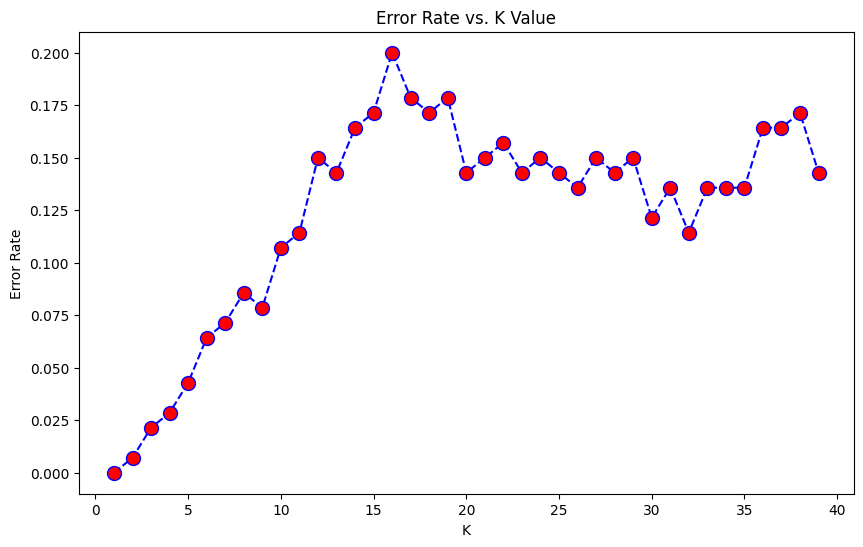

✅ Minimum Error is 0.0000 at K = 1


In [46]:
error_rate = []

# Will take some time depending on dataset size
print("🔄 Finding best K value (this might take a moment)...")

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    # Average error (1 - accuracy)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting the Error Rate vs K Value
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

# Find minimum error
optimal_k = error_rate.index(min(error_rate)) + 1
print(f"✅ Minimum Error is {min(error_rate):.4f} at K = {optimal_k}")


In [47]:
# Retrain with the optimal K found above
final_k = optimal_k  # Or set manually if graph is weird (e.g., final_k = 5)

final_model = KNeighborsClassifier(n_neighbors=final_k)
final_model.fit(X_train_scaled, y_train)
final_pred = final_model.predict(X_test_scaled)

print(f"🚀 Final Model Trained with K={final_k}!")
print(f"🏆 Final Accuracy: {accuracy_score(y_test, final_pred):.2%}")


🚀 Final Model Trained with K=1!
🏆 Final Accuracy: 100.00%


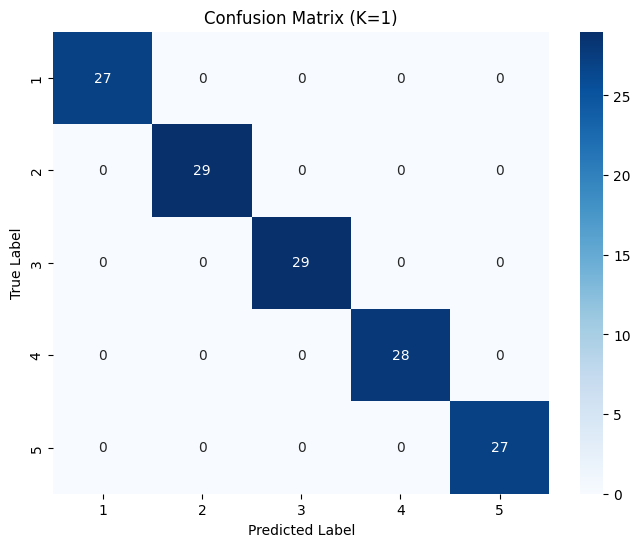

In [48]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, final_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names,
            yticklabels=target_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (K={final_k})')
plt.show()


In [49]:
random_idx = np.random.randint(0, len(X_test))
sample_user = X_test.iloc[random_idx]
sample_user_scaled = X_test_scaled.iloc[random_idx].values.reshape(1, -1)

# Get True Label
true_label_idx = y_test[random_idx]
true_label_name = le.inverse_transform([true_label_idx])[0]

# Predict
pred_label_idx = final_model.predict(sample_user_scaled)[0]
pred_label_name = le.inverse_transform([pred_label_idx])[0]

print(f"👤 User Index: {random_idx}")
print(f"📝 True Class:      {true_label_name}")
print(f"🤖 Predicted Class: {pred_label_name}")

if true_label_name == pred_label_name:
    print("✅ Prediction Correct!")
else:
    print("❌ Prediction Wrong!")

👤 User Index: 120
📝 True Class:      5
🤖 Predicted Class: 5
✅ Prediction Correct!


Hyperparameter Tuning (GridSearchCV)

In [50]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid (The options we want to test)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 2. Initialize the Grid Search
# cv=5 means "Cross Validation" - it tests 5 times per setting to be sure!
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    verbose=1,
    n_jobs=-1  # Use all computer cores for speed! ⚡
)

# 3. Fit the Grid Search (This takes a few seconds)
print("🤖 Tuning Hyperparameters... (Hold tight!)")
grid_search.fit(X_train_scaled, y_train)

# 4. Get the Results
print(f"\n✅ Tuning Complete!")
print(f"🏆 Best Parameters: {grid_search.best_params_}")
print(f"🥇 Best Cross-Val Accuracy: {grid_search.best_score_:.2%}")


🤖 Tuning Hyperparameters... (Hold tight!)
Fitting 5 folds for each of 28 candidates, totalling 140 fits

✅ Tuning Complete!
🏆 Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
🥇 Best Cross-Val Accuracy: 100.00%


In [51]:
# Get the best model directly
best_model = grid_search.best_estimator_

# Predict on Test Set
final_pred_tuned = best_model.predict(X_test_scaled)

print("🚀 Final Tuned Model Evaluation:\n")
print(classification_report(y_test, final_pred_tuned, target_names=target_names))

# Compare Accuracy
old_acc = accuracy_score(y_test, final_pred)  # From previous manual model
new_acc = accuracy_score(y_test, final_pred_tuned)

print(f"Old Accuracy: {old_acc:.2%}")
print(f"New Accuracy: {new_acc:.2%}")

if new_acc > old_acc:
    print("🎉 Optimization worked! The model improved!")
else:
    print("👍 The model was already great! No major improvement needed.")


🚀 Final Tuned Model Evaluation:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        29
           4       1.00      1.00      1.00        28
           5       1.00      1.00      1.00        27

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140

Old Accuracy: 100.00%
New Accuracy: 100.00%
👍 The model was already great! No major improvement needed.


In [52]:
import joblib

# 1. Define the list of columns exactly as they went into the model
# (This handles the One-Hot Encoding matching)
model_columns = list(X.columns)

# 2. Bundle everything into a dictionary
artifacts = {
    'model': best_model,              # The tuned KNN model
    'scaler': scaler,                 # The standard scaler
    'le': le,                         # The label encoder (for target)
    'model_columns': model_columns    # The feature names
}

# 3. Save to a file
joblib.dump(artifacts, 'mobile_segmenter_model.pkl')

print("✅ Model Artifacts Saved to 'mobile_segmenter_model.pkl'!")
print("🎉 Ready for deployment!")


✅ Model Artifacts Saved to 'mobile_segmenter_model.pkl'!
🎉 Ready for deployment!
